# Решение кейса МТС от команды "Лунная призма, дай мне деняк"  — ML-пайплайн предсказания высоты зданий

## Шаг 0. Установка окружения

In [1]:
import sys
!{sys.executable} -m pip install geopandas shapely pyproj folium scikit-learn lightgbm catboost matplotlib seaborn networkx rtree --quiet
print('Зависимости установлены')

Зависимости установлены


## Шаг 1. Импорт

In [3]:
import os, warnings
from functools import reduce

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import folium
import networkx as nx

from shapely import wkt
from shapely.validation import make_valid
from itertools import combinations

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, median_absolute_error
)
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    from catboost import CatBoostRegressor, Pool
    HAS_CB = True
except ImportError:
    HAS_CB = False

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print(f'Импорт библиотек выполнен, LightGBM: {HAS_LGB} , CatBoost: {HAS_CB}')

Импорт библиотек выполнен, LightGBM: True , CatBoost: True


## Шаг 2. Загрузка данных

In [5]:
SOURCE_FILES = {'A': 'cup_it_example_src_A.csv', 'B': 'cup_it_example_src_B.csv'}
GEOM_COLUMNS = {'A': 'geometry', 'B': 'wkt'}

def parse_geom(s):
    if pd.isna(s) or not str(s).strip(): return None
    try:
        g = wkt.loads(str(s))
        if g is None or g.is_empty: return None
        return g if g.is_valid else make_valid(g)
    except Exception: return None

def load_all_sources(source_files, geom_columns):
    frames = []
    for label, path in source_files.items():
        if not os.path.exists(path):
            print(f'Не найден: {path}'); continue
        ext = path.rsplit('.', 1)[-1].lower()
        if ext == 'csv':
            df = pd.read_csv(path, low_memory=False)
        elif ext in ('geojson', 'json'):
            df = gpd.read_file(path)
            df['geometry'] = df.geometry.apply(lambda g: g.wkt if g else None)
        else:
            print(f'Формат не поддерживается: {path}'); continue
        gcol = geom_columns.get(label, 'geometry')
        col  = gcol if gcol in df.columns else ('geometry' if 'geometry' in df.columns else None)
        if col is None:
            print(f'Нет колонки геометрии: {path}'); continue
        df = df.rename(columns={col: 'raw_geometry'})
        df['source'] = label
        df['src_row_id'] = label + '_' + df.index.astype(str)
        frames.append(df)
        print(f'    {label}: {len(df):,} записей')
    if not frames: raise FileNotFoundError('Ни один файл не загружен.')
    combined = pd.concat(frames, ignore_index=True)
    print(f'\n Итого: {len(combined):,} записей')
    return combined

df_raw = load_all_sources(SOURCE_FILES, GEOM_COLUMNS)
print(df_raw['source'].value_counts().to_string())

    A: 171,454 записей
    B: 161,076 записей

 Итого: 332,530 записей
source
A    171454
B    161076


## Шаг 3. Очистка

In [7]:
MIN_AREA, MAX_AREA = 20, 500_000

print('Запущен процесс очистки')
df_raw['geometry'] = df_raw['raw_geometry'].apply(parse_geom)
n0 = len(df_raw)
gdf = gpd.GeoDataFrame(df_raw[df_raw['geometry'].notna()].copy(), geometry='geometry', crs='EPSG:4326')
print(f'   Пустых геометрий: {n0 - len(gdf):,}')

gdf_m = gdf.to_crs('EPSG:32636')
gdf['area_m2'] = gdf_m.geometry.area
n1 = len(gdf)
gdf = gdf[gdf['area_m2'].between(MIN_AREA, MAX_AREA)].copy()
print(f'   По площади: {n1 - len(gdf):,}')

n2 = len(gdf)
gdf['_geom_wkb'] = gdf.geometry.to_wkb(hex=True)
gdf = gdf.drop_duplicates(subset=['_geom_wkb', 'source']).drop(columns='_geom_wkb')
print(f'   Дубликатов: {n2 - len(gdf):,}')

for col in ['height','stairs','avg_floor_height','gkh_floor_count_min','gkh_floor_count_max']:
    if col in gdf.columns:
        gdf[col] = pd.to_numeric(gdf[col], errors='coerce')

if 'height' in gdf.columns:
    bad = (gdf['height'] < 2) | (gdf['height'] > 500)
    print(f'   Аномальных высот: {bad.sum():,}')
    gdf.loc[bad, 'height'] = np.nan

if 'stairs' in gdf.columns:
    valid_stairs = gdf['stairs'].between(1, 199)
    floor_h = gdf['avg_floor_height'].fillna(3.0).clip(2.5, 5.0) if 'avg_floor_height' in gdf.columns else 3.0
    mask_r = gdf['height'].isna() & valid_stairs
    gdf.loc[mask_r, 'height'] = gdf.loc[mask_r, 'stairs'] * floor_h
    print(f'   Восстановлено через этажность: {mask_r.sum():,}')

BLD_TYPE_MAP = {
    'residential':'residential','apartments':'residential','house':'residential',
    'жилой':'residential','многоквартирный':'residential','жилое':'residential',
    'office':'office','offices':'office','офис':'office','бизнес-центр':'office','административное':'office',
    'retail':'retail','shop':'retail','supermarket':'retail','торговое':'retail','магазин':'retail','торговый':'retail',
    'industrial':'industrial','warehouse':'industrial','склад':'industrial','производственное':'industrial',
    'school':'social','hospital':'social','clinic':'social','university':'social','образовательное':'social','медицинское':'social',
    'garage':'garage','гараж':'garage',
}
BLD_TYPE_MEDIAN_H = {
    'residential':18.0,'office':28.0,'retail':7.0,'industrial':8.0,'social':12.0,'garage':3.5,'unknown':15.0
}

def vectorized_bld_type(df, bld_type_map, src_cols=('purpose_of_building', 'tags', 'title')):
    combined = pd.Series('', index=df.index, dtype='object')
    for col in src_cols:
        if col in df.columns:
            s = df[col].fillna('').astype(str).str.strip().str.lower()
            combined = combined.where(s.eq(''), combined + ' | ' + s)

    result = pd.Series('unknown', index=df.index, dtype='object')
    unresolved = combined.ne('')

    for key, mapped in bld_type_map.items():
        mask = unresolved & result.eq('unknown') & combined.str.contains(key, regex=False, na=False)
        if mask.any():
            result.loc[mask] = mapped

    return result

gdf['bld_type'] = vectorized_bld_type(gdf, BLD_TYPE_MAP)
gdf['bld_type_median_h'] = gdf['bld_type'].map(BLD_TYPE_MEDIAN_H)
gdf = gdf.reset_index(drop=True)
print(f'\n Итого: {len(gdf):,} записей')
print(gdf['bld_type'].value_counts().to_string())

Запущен процесс очистки
   Пустых геометрий: 0
   По площади: 26,824
   Дубликатов: 0
   Аномальных высот: 0
   Восстановлено через этажность: 0

 Итого: 305,706 записей
bld_type
residential    163877
unknown        116841
industrial      15732
office           5986
retail           3188
social             59
garage             23


## Шаг 4. Пространственное сопоставление

In [9]:
IOU_THRESHOLD = 0.3

def batch_jaccard(gdf_left, gdf_right, threshold=0.3, self_match=False):
    joined = gpd.sjoin(
        gdf_left[['src_row_id', 'geometry']],
        gdf_right[['src_row_id', 'geometry']],
        how='inner',
        predicate='intersects'
    ).rename(columns={'src_row_id_left': 'id_l', 'src_row_id_right': 'id_r'})

    if joined.empty:
        return pd.DataFrame(columns=['id_l', 'id_r', 'iou'])

    if self_match:
        joined = joined[joined['id_l'] < joined['id_r']]
        if joined.empty:
            return pd.DataFrame(columns=['id_l', 'id_r', 'iou'])

    gl = gdf_left.set_index('src_row_id')['geometry']
    gr = gdf_right.set_index('src_row_id')['geometry']

    def iou(il, ir):
        try:
            inter = gl[il].intersection(gr[ir]).area
            union = gl[il].union(gr[ir]).area
            return inter / union if union > 0 else 0.0
        except:
            return 0.0

    ious = np.array([iou(il, ir) for il, ir in zip(joined['id_l'], joined['id_r'])])
    mask = ious >= threshold

    return pd.DataFrame({
        'id_l': joined['id_l'].values[mask],
        'id_r': joined['id_r'].values[mask],
        'iou': ious[mask]
    })


print('Процесс сопоставления')
sources = sorted(gdf['source'].unique())
gdf_by_src = {s: gdf[gdf['source'] == s].copy() for s in sources}

G = nx.Graph()
G.add_nodes_from(gdf['src_row_id'])
all_pairs = []

for s in sources:
    print(f'   {s} - {s}...')
    pairs = batch_jaccard(gdf_by_src[s], gdf_by_src[s], IOU_THRESHOLD, self_match=True)
    print(f'   Внутри источника совпадений: {len(pairs):,}')
    if not pairs.empty:
        G.add_edges_from(zip(pairs['id_l'], pairs['id_r'], [{'weight': w} for w in pairs['iou']]))
    all_pairs.append(pairs)

for s1, s2 in combinations(sources, 2):
    print(f'   {s1} - {s2}...')
    pairs = batch_jaccard(gdf_by_src[s1], gdf_by_src[s2], IOU_THRESHOLD, self_match=False)
    print(f'   Между источниками совпадений: {len(pairs):,}')
    if not pairs.empty:
        G.add_edges_from(zip(pairs['id_l'], pairs['id_r'], [{'weight': w} for w in pairs['iou']]))
    all_pairs.append(pairs)

components = list(nx.connected_components(G))
building_map = {node: bid for bid, comp in enumerate(components) for node in comp}
gdf['building_id'] = gdf['src_row_id'].map(building_map)

print(f'Уникальных зданий: {len(components):,}')
print('Проверка качества сопоставления')
BASE_THRESHOLD = IOU_THRESHOLD
LOW_THRESHOLD = 0.2
HIGH_THRESHOLD = 0.4

STAIRS_DIFF_MAX = 3
HEIGHT_DIFF_MAX = 12

MAX_ALLOWED_PENALTY = 1

def norm_text(x):
    if pd.isna(x):
        return ''
    return ' '.join(str(x).strip().lower().split())

def text_equal_or_missing(a, b):
    a = norm_text(a)
    b = norm_text(b)
    if a == '' or b == '':
        return True
    return a == b

def to_num(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except:
        return np.nan

def numeric_close_or_missing(a, b, max_diff):
    a = to_num(a)
    b = to_num(b)
    if np.isnan(a) or np.isnan(b):
        return True
    return abs(a - b) <= max_diff

def compute_iou(geom1, geom2):
    try:
        inter = geom1.intersection(geom2).area
        union = geom1.union(geom2).area
        return inter / union if union > 0 else 0.0
    except:
        return 0.0

def pair_penalty(r1, r2, iou):
    penalty = 0

    # 1. Геометрическая близость
    if iou < BASE_THRESHOLD:
        return 999

    # 2. Чувствительность к порогу IoU
    if LOW_THRESHOLD <= iou < HIGH_THRESHOLD:
        penalty += 1

    # 3. Согласованность адреса после объединения 
    if 'gkh_address' in r1.index and 'gkh_address' in r2.index:
        if not text_equal_or_missing(r1['gkh_address'], r2['gkh_address']):
            penalty += 2

    if 'name_street' in r1.index and 'name_street' in r2.index:
        if not text_equal_or_missing(r1['name_street'], r2['name_street']):
            penalty += 1

    if 'number' in r1.index and 'number' in r2.index:
        if not text_equal_or_missing(r1['number'], r2['number']):
            penalty += 2

    if 'district' in r1.index and 'district' in r2.index:
        if not text_equal_or_missing(r1['district'], r2['district']):
            penalty += 1

    if 'stairs' in r1.index and 'stairs' in r2.index:
        if not numeric_close_or_missing(r1['stairs'], r2['stairs'], STAIRS_DIFF_MAX):
            penalty += 1

    if 'height' in r1.index and 'height' in r2.index:
        if not numeric_close_or_missing(r1['height'], r2['height'], HEIGHT_DIFF_MAX):
            penalty += 1

    if 'bld_type' in r1.index and 'bld_type' in r2.index:
        t1 = norm_text(r1['bld_type'])
        t2 = norm_text(r2['bld_type'])
        if t1 not in ['', 'unknown'] and t2 not in ['', 'unknown'] and t1 != t2:
            penalty += 1

    return penalty


# Разъединение ложных построек

gdf = gdf.copy()
gdf['_old_building_id'] = gdf['building_id']

new_building_ids = {}
next_bid = 0

component_logs = []
pair_logs = []

old_component_sizes = gdf.groupby('_old_building_id').size()

for old_bid, block in gdf.groupby('_old_building_id', sort=False):
    ids = block['src_row_id'].tolist()

    if len(ids) == 1:
        new_building_ids[ids[0]] = next_bid
        component_logs.append({
            'old_building_id': old_bid,
            'old_size': 1,
            'new_components': 1,
            'pairs_total': 0,
            'pairs_kept': 0,
            'pairs_removed': 0,
            'was_split': False
        })
        next_bid += 1
        continue

    G_local = nx.Graph()
    G_local.add_nodes_from(ids)

    rows_by_id = {row['src_row_id']: row for _, row in block.iterrows()}

    pairs_total = 0
    pairs_kept = 0
    pairs_removed = 0

    for id1, id2 in combinations(ids, 2):
        pairs_total += 1

        r1 = rows_by_id[id1]
        r2 = rows_by_id[id2]

        iou = compute_iou(r1.geometry, r2.geometry)
        penalty = pair_penalty(r1, r2, iou)

        keep_edge = penalty <= MAX_ALLOWED_PENALTY

        if keep_edge:
            G_local.add_edge(id1, id2)
            pairs_kept += 1
        else:
            pairs_removed += 1
            pair_logs.append({
                'old_building_id': old_bid,
                'id1': id1,
                'id2': id2,
                'iou': iou,
                'penalty': penalty
            })

    comps = list(nx.connected_components(G_local))

    for comp in comps:
        for node in comp:
            new_building_ids[node] = next_bid
        next_bid += 1

    component_logs.append({
        'old_building_id': old_bid,
        'old_size': len(ids),
        'new_components': len(comps),
        'pairs_total': pairs_total,
        'pairs_kept': pairs_kept,
        'pairs_removed': pairs_removed,
        'was_split': len(comps) > 1
    })

gdf['building_id_clean'] = gdf['src_row_id'].map(new_building_ids)

new_component_sizes = gdf.groupby('building_id_clean').size()

component_logs_df = pd.DataFrame(component_logs)
pair_logs_df = pd.DataFrame(pair_logs)

gdf['building_id'] = gdf['building_id_clean']
gdf = gdf.drop(columns=['_old_building_id'])

old_n = len(old_component_sizes)
new_n = len(new_component_sizes)
split_components = int(component_logs_df['was_split'].sum())
total_removed_pairs = int(component_logs_df['pairs_removed'].sum())
total_pairs_checked = int(component_logs_df['pairs_total'].sum())

print(f'Новых уникальных зданий после проверки качества валидации: {new_n:,}')
print(f'Разделенные постройки: {split_components:,}')
print(f'Проверка всех сопоставленных пар: {total_pairs_checked:,}')
print(f'Удалено некачественных связей: {total_removed_pairs:,}')
print(f'Добавленные уникальные здания после оценки качества: {new_n - old_n:,}')

Процесс сопоставления
   A - A...
   Внутри источника совпадений: 1,927
   B - B...
   Внутри источника совпадений: 153
   A - B...
   Между источниками совпадений: 79,525
Уникальных зданий: 225,382
Проверка качества сопоставления
Новых уникальных зданий после проверки качества валидации: 225,656
Разделенные постройки: 254
Проверка всех сопоставленных пар: 84,864
Удалено некачественных связей: 3,595
Добавленные уникальные здания после оценки качества: 274


## Шаг 5. Выбор высоты

In [11]:
SOURCE_PRIORITY = {'B': 0, 'A': 1}

def select_height_vectorized(gdf, priority):
    df = gdf.copy()
    df['_pri'] = df['source'].map(priority).fillna(99)

    best_h = pd.DataFrame(columns=['building_id', 'height_agg', 'height_source'])
    has_h = df[df['height'].notna() & df['height'].between(2, 500)].copy()
    if not has_h.empty:
        has_h['_wh'] = has_h['height'] * has_h['area_m2'].fillna(1.0)
        agg = (
            has_h.groupby(['building_id', 'source', '_pri'])
            .agg(_wh=('_wh', 'sum'), _w=('area_m2', lambda x: x.fillna(1.0).sum()))
            .reset_index()
        )
        agg['height_agg'] = agg['_wh'] / agg['_w']
        best_h = (
            agg.sort_values('_pri')
            .groupby('building_id', as_index=False)
            .first()
            .rename(columns={'source': 'height_source'})[['building_id', 'height_agg', 'height_source']]
        )

    geom_best = (
        df.sort_values('area_m2', ascending=False)
        .groupby('building_id', as_index=False)
        .first()[['building_id', 'geometry']]
    )
    repr_row = (
        df.sort_values(['building_id', '_pri'])
        .groupby('building_id', as_index=False)
        .first()
    )

    merge_parts = [
        repr_row[['building_id', 'area_m2'] + [c for c in ['name_street', 'number', 'district', 'gkh_address'] if c in repr_row.columns]],
        geom_best,
        best_h,
    ]

    if 'stairs' in df.columns:
        stairs_agg = df.groupby('building_id')['stairs'].max().reset_index(name='stairs')
        merge_parts.append(stairs_agg)

    if 'bld_type' in df.columns:
        known = df[df['bld_type'] != 'unknown'].sort_values('_pri')
        if not known.empty:
            type_best = known.groupby('building_id', as_index=False).first()[['building_id', 'bld_type', 'bld_type_median_h']]
            type_best = type_best.rename(columns={'bld_type': '_bt', 'bld_type_median_h': '_bmh'})
        else:
            type_best = pd.DataFrame(columns=['building_id', '_bt', '_bmh'])

        type_agg = repr_row[['building_id', 'bld_type', 'bld_type_median_h']].merge(
            type_best, on='building_id', how='left'
        )
        type_agg['bld_type'] = type_agg['_bt'].fillna(type_agg['bld_type'])
        type_agg['bld_type_median_h'] = type_agg['_bmh'].fillna(type_agg['bld_type_median_h'])
        type_agg = type_agg[['building_id', 'bld_type', 'bld_type_median_h']]
        merge_parts.append(type_agg)

    result = reduce(
        lambda left, right: left.merge(right, on='building_id', how='left'),
        merge_parts
    )
    assert len(result) == result['building_id'].nunique(), 'Merge создал дубликаты building_id'

    result['height'] = result['height_agg']
    result['height_source'] = result['height_source'].fillna('missing')
    result = result.drop(columns='height_agg', errors='ignore')
    return gpd.GeoDataFrame(result, geometry='geometry', crs='EPSG:4326')

gdf_unified = select_height_vectorized(gdf, SOURCE_PRIORITY)
n_known = gdf_unified['height'].notna().sum()
n_miss  = gdf_unified['height'].isna().sum()
print(f'Зданий: {len(gdf_unified):,} , высота: {n_known:,} ({n_known/len(gdf_unified)*100:.1f}%) , ML: {n_miss:,}')

Зданий: 225,656 , высота: 150,681 (66.8%) , ML: 74,975


---
# ML-ПАЙПЛАЙН (Этапы 1–5)

## Этап 0. Разделение на train_eval_set и predict_set

In [13]:
train_eval_set = gdf_unified[gdf_unified['height'].notna()].copy().reset_index(drop=True)
predict_set    = gdf_unified[gdf_unified['height'].isna()].copy().reset_index(drop=True)

assert predict_set['height'].isna().all(), 'ОШИБКА: predict_set содержит height!'

print(f'train_eval_set : {len(train_eval_set):,} зданий (height known)')
print(f'predict_set    : {len(predict_set):,} зданий (height missing → ML)')

h = train_eval_set['height']
print(f'\nВысоты в train_eval_set: min={h.min():.1f} | median={h.median():.1f} | mean={h.mean():.1f} | max={h.max():.1f}')

train_eval_set : 150,681 зданий (height known)
predict_set    : 74,975 зданий (height missing → ML)

Высоты в train_eval_set: min=2.5 | median=8.0 | mean=14.9 | max=462.0


## Этап 1. Feature Engineering

Признаки делятся на два класса:

**Безопасные** — зависят только от геометрии:
- `area_m2`, `area_log`, `perimeter`, `compactness`
- центроид `cx`, `cy` в метрах
- shape признаки: bbox_w, bbox_h, rectangularity, elongation

**Требуют fit на train_fold** — агрегаты, зависящие от target:
- grid stats: median height, std, density, mean area по ячейке 1000 м
- KNN признаки: mean/std/p25/p50/p75/min/max высот k ближайших соседей
- type prior: медианная высота по типу здания
- bld_type_enc: LabelEncoder (не содержит target, но fit на train для однородности)

In [15]:
print('Базовые геометрические признаки:')

def compute_base_features(df_gdf):

    gdf_m_local = df_gdf.to_crs('EPSG:32636')
    centroids   = gdf_m_local.geometry.centroid

    result = df_gdf.copy()
    result['cx']          = centroids.x
    result['cy']          = centroids.y
    result['centroid_lat'] = df_gdf.geometry.centroid.y
    result['centroid_lon'] = df_gdf.geometry.centroid.x

    area      = gdf_m_local.geometry.area
    perim     = gdf_m_local.geometry.length
    result['area_m2']     = area
    result['area_log']    = np.log1p(area.clip(lower=0))
    result['perimeter']   = perim
    result['compactness'] = 4 * np.pi * area / (perim**2 + 1e-9)

    bounds = gdf_m_local.geometry.bounds   # minx, miny, maxx, maxy
    bbox_w = bounds['maxx'] - bounds['minx']
    bbox_h = bounds['maxy'] - bounds['miny']
    bbox_area = (bbox_w * bbox_h).clip(lower=1.0)

    result['bbox_w']         = bbox_w.values
    result['bbox_h']         = bbox_h.values
    result['rectangularity'] = (area / bbox_area).clip(0, 1).values
    result['elongation']     = (np.maximum(bbox_w, bbox_h) / (np.minimum(bbox_w, bbox_h).clip(lower=1))).values

    return result


train_eval_set = compute_base_features(train_eval_set)
predict_set    = compute_base_features(predict_set)

BASE_FEATS = ['area_m2','area_log','perimeter','compactness',
              'cx','cy','bbox_w','bbox_h','rectangularity','elongation']

print(f'Базовых признаков: {len(BASE_FEATS)} — {BASE_FEATS}')

Базовые геометрические признаки:
Базовых признаков: 10 — ['area_m2', 'area_log', 'perimeter', 'compactness', 'cx', 'cy', 'bbox_w', 'bbox_h', 'rectangularity', 'elongation']


## Spatial GroupKFold

Разбиваем карту на ячейки 1000×1000 м. Каждая ячейка → один `spatial_group`.
Это симулирует предсказание на незнакомом районе.

Уникальных ячеек: 609 , folds: 5


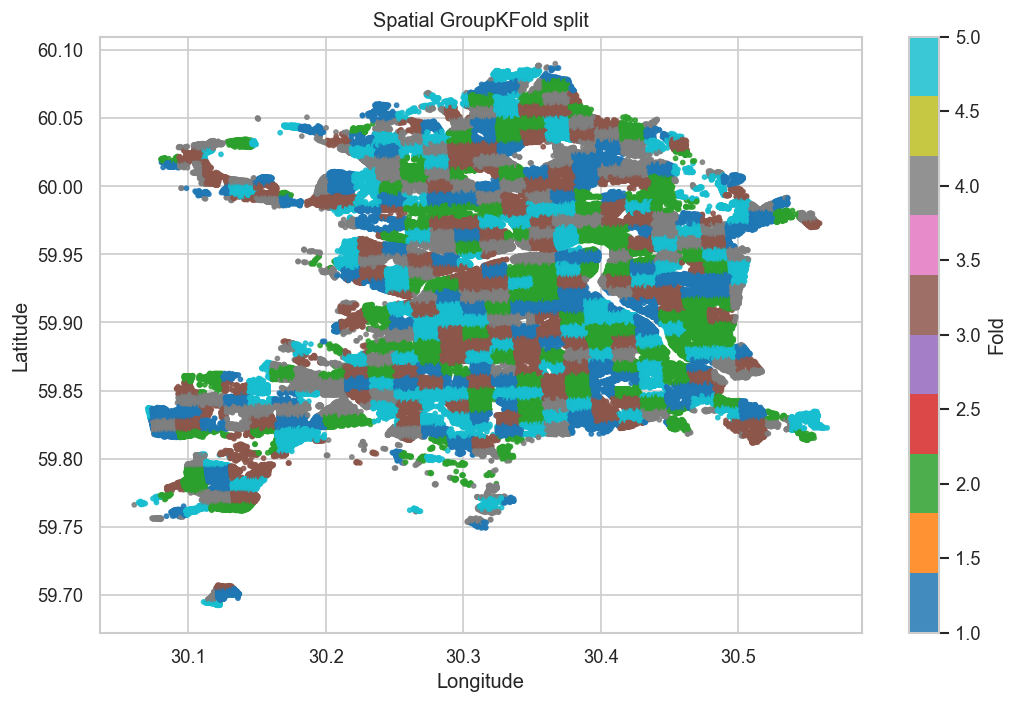

In [17]:
GRID_SIZE = 1000.0 

def compute_grid_id(cx, cy, grid_size):
    gx = np.floor(np.asarray(cx) / grid_size).astype(np.int32)
    gy = np.floor(np.asarray(cy) / grid_size).astype(np.int32)
    return (gx.astype(np.int64) << 32) + (gy.astype(np.int64) & 0xffffffff)

train_eval_set['grid_id'] = compute_grid_id(train_eval_set['cx'], train_eval_set['cy'], GRID_SIZE)
train_eval_set['spatial_group'] = train_eval_set['grid_id'].astype(str)

group_counts = train_eval_set['spatial_group'].value_counts()
rare = group_counts[group_counts < 10].index
train_eval_set.loc[train_eval_set['spatial_group'].isin(rare), 'spatial_group'] = 'rare_cells'

n_unique_groups = train_eval_set['spatial_group'].nunique()
N_SPLITS = min(5, max(2, n_unique_groups))
print(f'Уникальных ячеек: {n_unique_groups} , folds: {N_SPLITS}')

# Визуализация spatial split
fig, ax = plt.subplots(figsize=(9, 6))
groups_arr = train_eval_set['spatial_group'].values
gkf = GroupKFold(n_splits=N_SPLITS)
fold_labels = np.zeros(len(train_eval_set), dtype=int)
for fold_i, (_, val_idx) in enumerate(gkf.split(train_eval_set, groups=groups_arr)):
    fold_labels[val_idx] = fold_i + 1
scatter = ax.scatter(train_eval_set['centroid_lon'], train_eval_set['centroid_lat'],
                     c=fold_labels, s=6, cmap='tab10', alpha=0.85)
ax.set_title('Spatial GroupKFold split')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.colorbar(scatter, ax=ax, label='Fold')
plt.tight_layout()
plt.show()

## Функции feature engineering (fit только на train_fold)

In [19]:

KNN_K_LIST = [5, 15, 50]  
TARGET     = 'height'


def fit_grid_stats(train_df, grid_size=GRID_SIZE):

    gid = compute_grid_id(train_df['cx'].to_numpy(), train_df['cy'].to_numpy(), grid_size)
    df = train_df.assign(_gid=gid)

    grid_stats = (
        df.groupby('_gid')
        .agg(
            grid_height_median=(TARGET, 'median'),
            grid_height_mean=(TARGET, 'mean'),
            grid_height_std=(TARGET, 'std'),
            grid_height_p25=(TARGET, lambda x: x.quantile(0.25)),
            grid_height_p75=(TARGET, lambda x: x.quantile(0.75)),
            grid_density=('_gid', 'count'),
            grid_area_mean=('area_m2', 'mean'),
        )
        .reset_index()
    )

    global_stats = {
        'grid_height_median': train_df[TARGET].median(),
        'grid_height_mean':   train_df[TARGET].mean(),
        'grid_height_std':    train_df[TARGET].std(),
        'grid_height_p25':    train_df[TARGET].quantile(0.25),
        'grid_height_p75':    train_df[TARGET].quantile(0.75),
        'grid_density':       max(len(train_df) / max(grid_stats['_gid'].nunique(), 1), 1.0),
        'grid_area_mean':     train_df['area_m2'].mean(),
    }
    return grid_stats, global_stats, grid_size


def apply_grid_stats(df, grid_stats, global_stats, grid_size):
    gid = compute_grid_id(df['cx'].to_numpy(), df['cy'].to_numpy(), grid_size)
    gid_df = pd.DataFrame({'_gid': gid}, index=df.index)
    stat_cols = [c for c in grid_stats.columns if c != '_gid']

    merged_stats = gid_df.merge(grid_stats, on='_gid', how='left').drop(columns='_gid')
    merged_stats = merged_stats.fillna(pd.Series(global_stats))
    merged = pd.concat(
        [df.reset_index(drop=True), merged_stats.reset_index(drop=True)],
        axis=1
    )
    return merged, stat_cols


def fit_knn(train_df):
    coords = np.column_stack([
        train_df['cx'].to_numpy(dtype=np.float32, na_value=0.0),
        train_df['cy'].to_numpy(dtype=np.float32, na_value=0.0),
    ])
    tr_heights = train_df[TARGET].to_numpy(dtype=np.float32, na_value=np.nan)
    nn_model = NearestNeighbors(n_neighbors=max(KNN_K_LIST) + 1, n_jobs=1)
    nn_model.fit(coords)
    return nn_model, tr_heights, coords


def apply_knn(nn_model, tr_heights, query_df, k_list, leave_one_out=False):

    q_coords = np.column_stack([
        query_df['cx'].to_numpy(dtype=np.float32, na_value=0.0),
        query_df['cy'].to_numpy(dtype=np.float32, na_value=0.0),
    ])
    max_k = max(k_list) + (1 if leave_one_out else 0)
    _, idxs = nn_model.kneighbors(q_coords, n_neighbors=max_k)
    start = 1 if leave_one_out else 0

    feat_dict = {}
    log_suffixes = ('mean', 'p50', 'p75', 'max')
    for k in k_list:
        nb = tr_heights[idxs[:, start:start + k]]
        p25, p50, p75 = np.quantile(nb, [0.25, 0.50, 0.75], axis=1)
        raw = {
            f'knn{k}_mean': nb.mean(axis=1),
            f'knn{k}_std':  nb.std(axis=1),
            f'knn{k}_p25':  p25,
            f'knn{k}_p50':  p50,
            f'knn{k}_p75':  p75,
            f'knn{k}_min':  nb.min(axis=1),
            f'knn{k}_max':  nb.max(axis=1),
        }
        for name, arr in raw.items():
            feat_dict[name] = np.log1p(arr) if name.endswith(log_suffixes) else arr

    knn_df = pd.DataFrame(feat_dict, index=query_df.index)
    return knn_df, list(knn_df.columns)


def fit_type_prior(train_df):
    prior = train_df.groupby('bld_type')[TARGET].median().to_dict()
    global_med = train_df[TARGET].median()
    return prior, global_med


def apply_type_prior(df, prior, global_med):
    return df['bld_type'].map(prior).fillna(global_med).to_numpy(dtype=np.float32).reshape(-1, 1)


def fit_type_encoder(train_df):
    known_types = pd.Index(train_df['bld_type'].fillna('unknown').unique())
    if 'unknown' not in known_types:
        known_types = known_types.insert(len(known_types), 'unknown')
    le = LabelEncoder()
    le.fit(known_types.tolist())
    return le, set(known_types.tolist())


def safe_label_encode(series, encoder, known_types):
    safe = series.fillna('unknown')
    safe = safe.where(safe.isin(known_types), 'unknown')
    return encoder.transform(safe).astype(np.float32)


def build_feature_matrix(
    df,
    *,
    base_feats,
    grid_stats,
    global_stats,
    grid_size,
    nn_model,
    tr_heights,
    type_prior,
    global_med,
    label_encoder,
    known_types,
    is_train_fold
):
    df_g, grid_cols = apply_grid_stats(df, grid_stats, global_stats, grid_size)
    knn_df, knn_cols = apply_knn(
        nn_model,
        tr_heights,
        df,
        KNN_K_LIST,
        leave_one_out=is_train_fold,
    )
    feats = pd.DataFrame(index=df.index)

    for f in base_feats:
        feats[f] = df_g[f].values if f in df_g.columns else df[f].values
    for col in grid_cols:
        feats[col] = df_g[col].values
    for col in knn_cols:
        feats[col] = knn_df[col].values

    feats['type_prior'] = apply_type_prior(df, type_prior, global_med).ravel()
    feats['bld_type_enc'] = safe_label_encode(df['bld_type'], label_encoder, known_types)
    return feats


def prepare_catboost_matrix(X_df, bld_type_series, imputer=None):
    X_cb = X_df.drop(columns=['bld_type_enc'], errors='ignore').copy()
    X_cb['bld_type'] = bld_type_series.fillna('unknown').values
    num_cols_cb = [c for c in X_cb.columns if c != 'bld_type']

    if imputer is None:
        imputer = SimpleImputer(strategy='median')
        X_cb[num_cols_cb] = imputer.fit_transform(X_cb[num_cols_cb])
    else:
        X_cb[num_cols_cb] = imputer.transform(X_cb[num_cols_cb])

    cat_idx = [list(X_cb.columns).index('bld_type')]
    return X_cb, num_cols_cb, cat_idx, imputer


print('Функции feature engineering составлены')

Функции feature engineering составлены


## Этап 2. OOF-обучение: LightGBM + CatBoost + Baselines

Для каждого fold:
1. fit grid_stats, KNN, type_prior, LabelEncoder на `train_fold`
2. transform `val_fold`
3. обучаем LightGBM и CatBoost с `sample_weight`
4. предсказываем на `val_fold`

In [35]:
print('OOF обучение')

groups_arr = train_eval_set['spatial_group'].values
y_all      = train_eval_set[TARGET].values
gkf        = GroupKFold(n_splits=N_SPLITS)

oof_lgb = np.full(len(train_eval_set), np.nan)
oof_cb  = np.full(len(train_eval_set), np.nan)

fold_results = []
FEATURE_NAMES = None
best_lgb_iteration = 500
best_cb_iteration = 500

for fold_i, (tr_idx, val_idx) in enumerate(gkf.split(train_eval_set, groups=groups_arr), start=1):
    print(f'\n── Fold {fold_i}/{N_SPLITS} ──────────────────────────────')
    train_fold = train_eval_set.iloc[tr_idx].copy().reset_index(drop=True)
    val_fold   = train_eval_set.iloc[val_idx].copy().reset_index(drop=True)
    print(f'   train={len(train_fold):,} | val={len(val_fold):,}')

    # ── 1. Fit всех encoder/stats только на train_fold ───────────────
    grid_stats, global_stats, gs = fit_grid_stats(train_fold, GRID_SIZE)
    nn_model, tr_heights, _ = fit_knn(train_fold)
    type_prior, global_med = fit_type_prior(train_fold)
    le, known_types = fit_type_encoder(train_fold)

    # ── 2. Feature matrices ──────────────────────────────────────────
    X_tr = build_feature_matrix(
        train_fold,
        base_feats=BASE_FEATS,
        grid_stats=grid_stats,
        global_stats=global_stats,
        grid_size=gs,
        nn_model=nn_model,
        tr_heights=tr_heights,
        type_prior=type_prior,
        global_med=global_med,
        label_encoder=le,
        known_types=known_types,
        is_train_fold=True,
    )
    X_val = build_feature_matrix(
        val_fold,
        base_feats=BASE_FEATS,
        grid_stats=grid_stats,
        global_stats=global_stats,
        grid_size=gs,
        nn_model=nn_model,
        tr_heights=tr_heights,
        type_prior=type_prior,
        global_med=global_med,
        label_encoder=le,
        known_types=known_types,
        is_train_fold=False,
    )
    if FEATURE_NAMES is None:
        FEATURE_NAMES = list(X_tr.columns)

    # Imputer (fit на train_fold)
    imp = SimpleImputer(strategy='median')
    X_tr_imp  = imp.fit_transform(X_tr)
    X_val_imp = imp.transform(X_val)

    y_tr_log  = np.log1p(train_fold[TARGET].values)
    y_val_log = np.log1p(val_fold[TARGET].values)

    # ── Sample weights (усиливаем высокие здания) ─────────────────────
    h_tr = train_fold[TARGET].values
    sw = np.ones(len(h_tr), dtype=float)
    sw[h_tr > 30] = 10
    sw[h_tr > 50] = 15
    sw[h_tr > 70] = 20

    lgb_mae = np.nan
    cb_mae = np.nan

    # ── LightGBM ──────────────────────────────────────────────────────
    if HAS_LGB:
        lgb_model = lgb.LGBMRegressor(
            n_estimators=2000, num_leaves=127, learning_rate=0.02,
            subsample=0.8, colsample_bytree=0.8,
            min_child_samples=20, reg_alpha=0.05, reg_lambda=0.1,
            random_state=42, verbose=-1, n_jobs=-1,
        )
        lgb_model.fit(
            X_tr_imp, y_tr_log,
            sample_weight=sw,
            eval_set=[(X_val_imp, y_val_log)],
            callbacks=[lgb.early_stopping(300, verbose=False), lgb.log_evaluation(500)]
        )
        oof_lgb[val_idx] = np.expm1(lgb_model.predict(X_val_imp))
        lgb_mae = mean_absolute_error(val_fold[TARGET].values, oof_lgb[val_idx])
        best_lgb_iteration = max(best_lgb_iteration, getattr(lgb_model, 'best_iteration_', 500))
        print(f'   LightGBM MAE={lgb_mae:.2f} м')

    # ── CatBoost ──────────────────────────────────────────────────────
    if HAS_CB:
        X_tr_cb, num_cols_cb, cat_idx, imp_cb = prepare_catboost_matrix(X_tr, train_fold['bld_type'])
        X_val_cb, _, _, _ = prepare_catboost_matrix(X_val, val_fold['bld_type'], imputer=imp_cb)

        cb_train = Pool(X_tr_cb, y_tr_log, weight=sw, cat_features=cat_idx)
        cb_val   = Pool(X_val_cb, y_val_log, cat_features=cat_idx)

        cb_model = CatBoostRegressor(
            iterations=2000, learning_rate=0.02, depth=8,
            l2_leaf_reg=3, random_seed=42,
            verbose=0, early_stopping_rounds=300,
            loss_function='RMSE',
            eval_metric='MAE'
        )
        cb_model.fit(cb_train, eval_set=cb_val)
        oof_cb[val_idx] = np.expm1(cb_model.predict(X_val_cb))
        cb_mae = mean_absolute_error(val_fold[TARGET].values, oof_cb[val_idx])
        best_cb_iteration = max(best_cb_iteration, getattr(cb_model, 'best_iteration_', 500))
        print(f'   CatBoost  MAE={cb_mae:.2f} м')

    fold_results.append({
        'fold': fold_i,
        'n_val': len(val_idx),
        'lgb_mae': lgb_mae if HAS_LGB else np.nan,
        'cb_mae':  cb_mae  if HAS_CB  else np.nan,
    })

print('\nOOF обучение завершено')

OOF обучение

── Fold 1/5 ──────────────────────────────
   train=120,545 | val=30,136
[500]	valid_0's l2: 0.431803
[1000]	valid_0's l2: 0.421703
[1500]	valid_0's l2: 0.415794
[2000]	valid_0's l2: 0.412829
   LightGBM MAE=6.78 м
   CatBoost  MAE=7.24 м

── Fold 2/5 ──────────────────────────────
   train=120,544 | val=30,137
[500]	valid_0's l2: 0.414738
[1000]	valid_0's l2: 0.406229
[1500]	valid_0's l2: 0.402116
[2000]	valid_0's l2: 0.400059
   LightGBM MAE=6.97 м
   CatBoost  MAE=7.28 м

── Fold 3/5 ──────────────────────────────
   train=120,545 | val=30,136
[500]	valid_0's l2: 0.42267
[1000]	valid_0's l2: 0.412435
[1500]	valid_0's l2: 0.407082
[2000]	valid_0's l2: 0.403913
   LightGBM MAE=6.53 м
   CatBoost  MAE=7.03 м

── Fold 4/5 ──────────────────────────────
   train=120,545 | val=30,136
[500]	valid_0's l2: 0.384212
[1000]	valid_0's l2: 0.375587
[1500]	valid_0's l2: 0.371462
[2000]	valid_0's l2: 0.369184
   LightGBM MAE=6.61 м
   CatBoost  MAE=6.94 м

── Fold 5/5 ───────────────

## Этап 3. Оценка модели на OOF

In [37]:

CARD_BINS   = [0, 15, 27, 36, 51, 63, 600]
CARD_LABELS = ['до 15м', '16–27м', '28–36м', '37–51м', '52–63м', 'выше 63м']
CARD_COLORS = ['#013220','#90ee90','#ffff00','#ffa500','#ff0000','#8b00ff']

y_true = train_eval_set[TARGET].values

def full_metrics(y_true, y_pred, name):

    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    medae = median_absolute_error(y_true, y_pred)
    p90   = np.percentile(np.abs(y_true - y_pred), 90)
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
            'MAPE%': mape, 'MedAE': medae, 'P90': p90}

comparison_rows = []


global_med = np.median(y_true)
comparison_rows.append(full_metrics(y_true, np.full_like(y_true, global_med), 'Baseline: global median'))

type_med_map = train_eval_set.groupby('bld_type')[TARGET].median()
pred_type = train_eval_set['bld_type'].map(type_med_map).fillna(global_med).values
comparison_rows.append(full_metrics(y_true, pred_type, 'Baseline: median by type'))


if HAS_LGB and not np.isnan(oof_lgb).all():
    oof_lgb_clipped = np.clip(oof_lgb, 2.0, 500.0)
    comparison_rows.append(full_metrics(y_true, oof_lgb_clipped, 'LightGBM (OOF)'))

if HAS_CB and not np.isnan(oof_cb).all():
    oof_cb_clipped = np.clip(oof_cb, 2.0, 500.0)
    comparison_rows.append(full_metrics(y_true, oof_cb_clipped, 'CatBoost (OOF)'))

df_comparison = pd.DataFrame(comparison_rows)

print('\nСравнение моделей:')
print(df_comparison.to_string(index=False, float_format='%.3f'))

# ── Лучшая модель ─────────────────────────────────────────────────────────
ml_rows = df_comparison[df_comparison['model'].str.contains('LightGBM|CatBoost')]
if not ml_rows.empty:
    best_name = ml_rows.loc[ml_rows['MAE'].idxmin(), 'model']
    best_oof  = oof_lgb_clipped if 'LightGBM' in best_name else oof_cb_clipped
    best_row  = ml_rows.loc[ml_rows['MAE'].idxmin()].to_dict()
    print(f'\nЛучшая модель: {best_name} | MAE={best_row["MAE"]:.2f} м | R²={best_row["R2"]:.3f}')
else:
    best_name = 'GlobalMedian'
    best_oof  = np.full_like(y_true, global_med)
    best_row  = comparison_rows[0]

# ── MAE по группам высот ────────────────────────────────────────────────
groups_arr_val = pd.cut(y_true, bins=CARD_BINS, labels=CARD_LABELS)
print('\nMAE по группам высот (OOF, лучшая модель):')
group_mae_list, group_cnt_list = [], []
for g in CARD_LABELS:
    m = groups_arr_val == g
    if m.sum() > 5:
        mae_g  = mean_absolute_error(y_true[m], best_oof[m])
        rmse_g = np.sqrt(mean_squared_error(y_true[m], best_oof[m]))
        print(f'  {g:>10s}: MAE={mae_g:.2f} м  RMSE={rmse_g:.2f} м  n={m.sum():,}')
        group_mae_list.append(mae_g)
    else:
        group_mae_list.append(0.0)
    group_cnt_list.append(int(m.sum()))


Сравнение моделей:
                   model    MAE   RMSE     R2  MAPE%  MedAE    P90
 Baseline: global median 10.000 16.758 -0.206 61.292  3.500 25.000
Baseline: median by type  9.832 16.071 -0.109 69.657  5.400 23.100
          LightGBM (OOF)  6.760 12.846  0.291 57.910  2.651 19.367
          CatBoost (OOF)  7.177 13.116  0.261 70.507  3.042 20.395

Лучшая модель: LightGBM (OOF) | MAE=6.76 м | R²=0.291

MAE по группам высот (OOF, лучшая модель):
      до 15м: MAE=3.75 м  RMSE=7.68 м  n=106,582
      16–27м: MAE=8.32 м  RMSE=10.15 м  n=15,898
      28–36м: MAE=10.21 м  RMSE=13.82 м  n=15,598
      37–51м: MAE=18.78 м  RMSE=22.82 м  n=7,433
      52–63м: MAE=26.57 м  RMSE=31.42 м  n=2,854
    выше 63м: MAE=48.53 м  RMSE=56.04 м  n=2,316


## Этап 4. Графики валидации

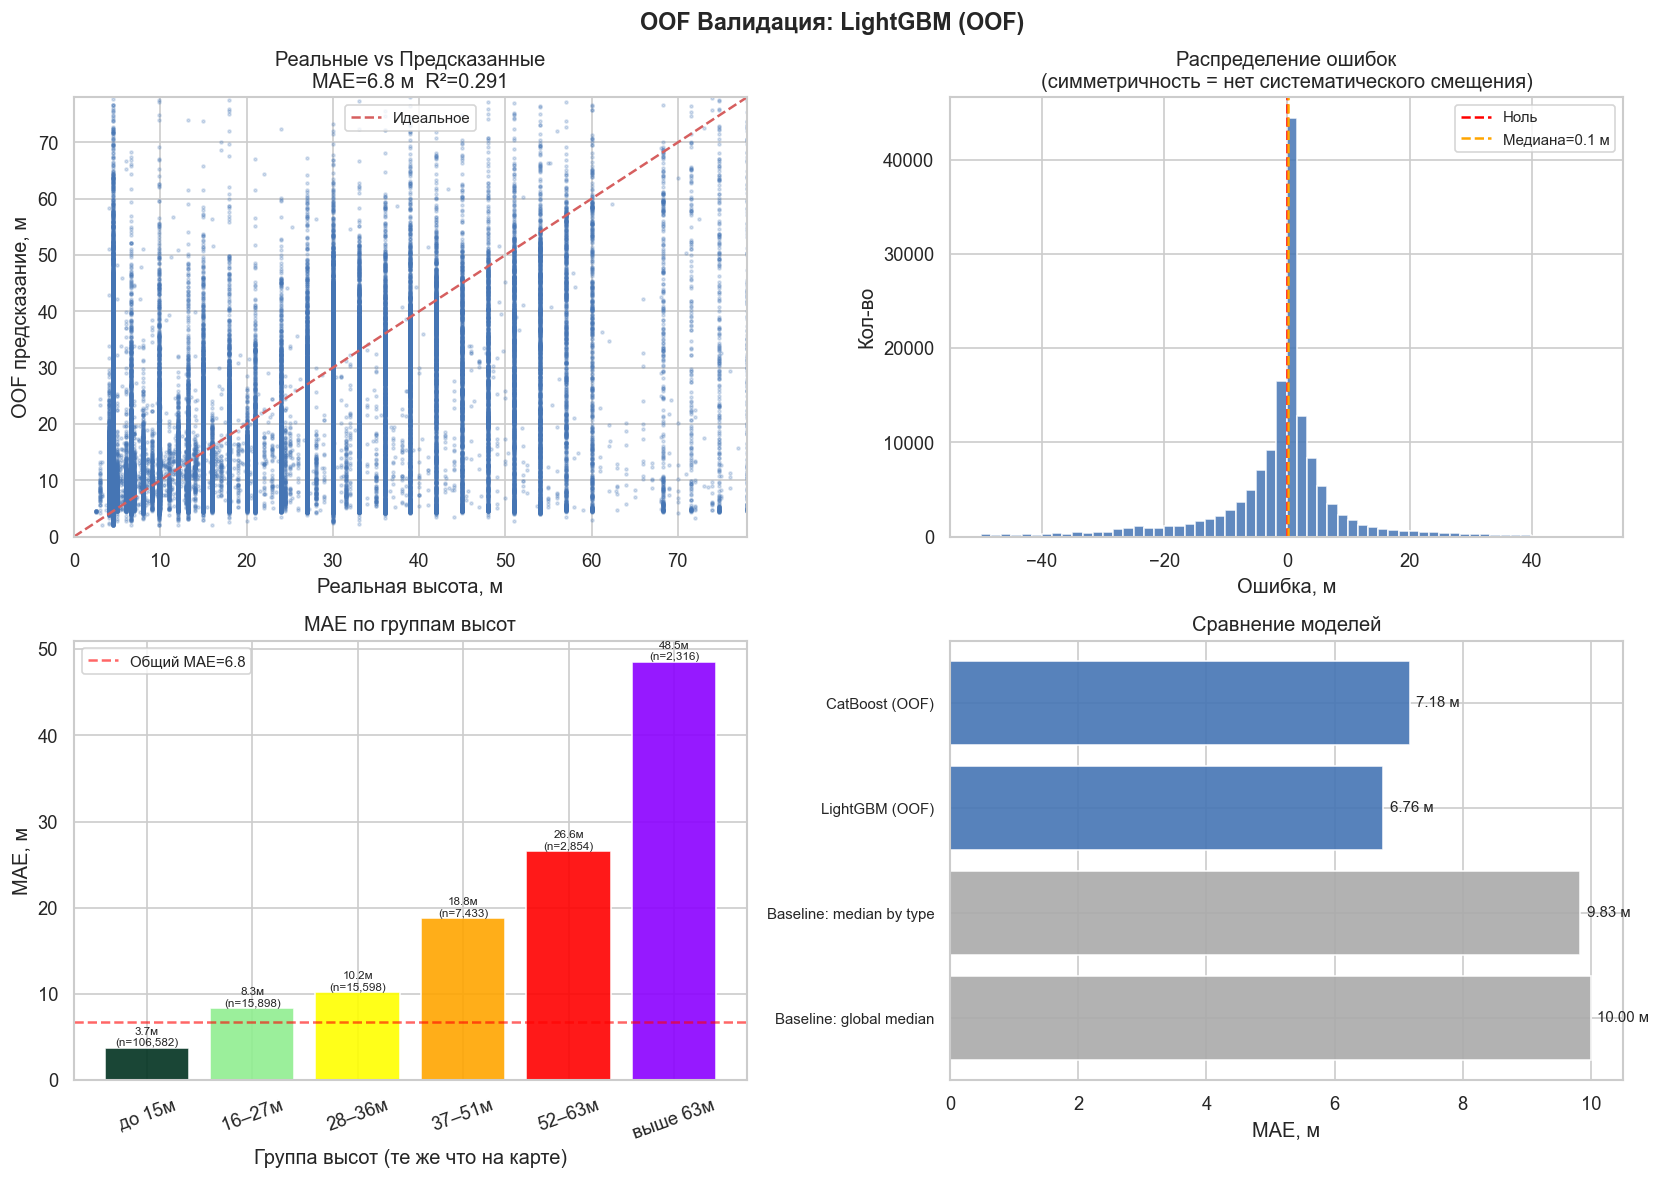

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'OOF Валидация: {best_name}', fontsize=14, fontweight='bold')

# 1. Реальные vs Предсказанные
ax = axes[0, 0]
lim = min(float(np.percentile(y_true, 99)), 150)
msk = (y_true <= lim) & (best_oof <= lim)
ax.scatter(y_true[msk], best_oof[msk], s=3, alpha=0.22, color='#4575b4')
ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Идеальное')
ax.set_xlabel('Реальная высота, м'); ax.set_ylabel('OOF предсказание, м')
ax.set_title(f'Реальные vs Предсказанные\nMAE={best_row["MAE"]:.1f} м  R²={best_row["R2"]:.3f}')
ax.legend(fontsize=9); ax.set_xlim(0, lim); ax.set_ylim(0, lim)

# 2. Распределение ошибок
ax = axes[0, 1]
res = best_oof - y_true
ax.hist(res[np.abs(res) < 50], bins=60, color='#4575b4', edgecolor='white', alpha=0.85)
ax.axvline(0,              color='red',    ls='--', lw=1.5, label='Ноль')
ax.axvline(np.median(res), color='orange', ls='--', lw=1.5, label=f'Медиана={np.median(res):.1f} м')
ax.set_xlabel('Ошибка, м'); ax.set_ylabel('Кол-во')
ax.set_title('Распределение ошибок\n(симметричность = нет систематического смещения)')
ax.legend(fontsize=9)

# 3. MAE по группам
ax = axes[1, 0]
bars = ax.bar(CARD_LABELS, group_mae_list, color=CARD_COLORS, edgecolor='white', alpha=0.9)
ax.axhline(best_row['MAE'], color='red', ls='--', alpha=0.6, label=f'Общий MAE={best_row["MAE"]:.1f}')
ax.set_xlabel('Группа высот (те же что на карте)'); ax.set_ylabel('MAE, м')
ax.set_title('MAE по группам высот'); ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=20)
for bar, v, n in zip(bars, group_mae_list, group_cnt_list):
    if v > 0:
        ax.text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}м\n(n={n:,})', ha='center', fontsize=7)

# 4. Сравнение моделей
ax = axes[1, 1]
maes = df_comparison['MAE'].values
names = df_comparison['model'].values
colors_bar = ['#4575b4' if 'Light' in n or 'Cat' in n else '#aaaaaa' for n in names]
bars2 = ax.barh(range(len(names)), maes, color=colors_bar, edgecolor='white', alpha=0.9)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('MAE, м'); ax.set_title('Сравнение моделей')
for bar, v in zip(bars2, maes):
    ax.text(v+0.1, bar.get_y()+bar.get_height()/2, f'{v:.2f} м', va='center', fontsize=9)

plt.tight_layout(); plt.savefig('validation.png', bbox_inches='tight'); plt.show()

## Этап 5. Финальная модель на всём train_eval_set

После честной OOF-оценки обучаем финальную модель на **всех** известных высотах.
Feature engineering fit на всём train_eval_set применяем к predict_set.

In [41]:
print(f'Финальная модель: {best_name}')

grid_stats_f, global_stats_f, gs_f = fit_grid_stats(train_eval_set, GRID_SIZE)
nn_model_f, tr_heights_f, _ = fit_knn(train_eval_set)
type_prior_f, global_med_f = fit_type_prior(train_eval_set)
le_f, known_types_f = fit_type_encoder(train_eval_set)

X_final = build_feature_matrix(
    train_eval_set,
    base_feats=BASE_FEATS,
    grid_stats=grid_stats_f,
    global_stats=global_stats_f,
    grid_size=gs_f,
    nn_model=nn_model_f,
    tr_heights=tr_heights_f,
    type_prior=type_prior_f,
    global_med=global_med_f,
    label_encoder=le_f,
    known_types=known_types_f,
    is_train_fold=True,
)
FEAT_NAMES = list(X_final.columns)
imp_f = SimpleImputer(strategy='median')
X_final_imp = imp_f.fit_transform(X_final)
y_final_log = np.log1p(train_eval_set[TARGET].values)

sw_final = np.ones(len(train_eval_set), dtype=float)
sw_final[train_eval_set[TARGET].values > 30] = 1.5
sw_final[train_eval_set[TARGET].values > 50] = 2.0
sw_final[train_eval_set[TARGET].values > 70] = 2.5

# Обучаем лучшую модель
if 'LightGBM' in best_name and HAS_LGB:
    n_iters = max(200, best_lgb_iteration + 50)
    final_model = lgb.LGBMRegressor(
        n_estimators=n_iters, num_leaves=127, learning_rate=0.02,
        subsample=0.8, colsample_bytree=0.8,
        min_child_samples=20, reg_alpha=0.05, reg_lambda=0.1,
        random_state=42, verbose=-1, n_jobs=1,
    )
    final_model.fit(X_final_imp, y_final_log, sample_weight=sw_final)
    imp_cb_f = None
    num_cols_cb = None
elif 'CatBoost' in best_name and HAS_CB:
    X_final_cb, num_cols_cb, cat_idx_f, imp_cb_f = prepare_catboost_matrix(X_final, train_eval_set['bld_type'])
    cb_pool_f = Pool(X_final_cb, y_final_log, weight=sw_final, cat_features=cat_idx_f)
    final_model = CatBoostRegressor(
        iterations=max(200, best_cb_iteration + 50),
        learning_rate=0.02, depth=8, l2_leaf_reg=3,
        random_seed=42, verbose=0, loss_function='RMSE',
    )
    final_model.fit(cb_pool_f)
else:
    final_model = None
    imp_cb_f = None
    num_cols_cb = None

print('Финальная модель обучена')


if not predict_set.empty:
    X_pred = build_feature_matrix(
        predict_set,
        base_feats=BASE_FEATS,
        grid_stats=grid_stats_f,
        global_stats=global_stats_f,
        grid_size=gs_f,
        nn_model=nn_model_f,
        tr_heights=tr_heights_f,
        type_prior=type_prior_f,
        global_med=global_med_f,
        label_encoder=le_f,
        known_types=known_types_f,
        is_train_fold=False,
    )

    if 'CatBoost' in best_name and HAS_CB:
        X_pred_cb, _, _, _ = prepare_catboost_matrix(X_pred, predict_set['bld_type'], imputer=imp_cb_f)
        predicted = np.expm1(final_model.predict(X_pred_cb))
    else:
        X_pred_imp = imp_f.transform(X_pred)
        predicted = np.expm1(final_model.predict(X_pred_imp))

    predicted = np.clip(predicted, 2.5, 250.0)


    if 'bld_type' in predict_set.columns:
        prior = predict_set['bld_type'].map(type_prior_f).fillna(global_med_f).values
        blend = np.where(predict_set['bld_type'].fillna('unknown').values != 'unknown', 0.05, 0.0)
        predicted = predicted * (1 - blend) + prior * blend

    predict_set = predict_set.copy()
    predict_set['predicted_height'] = predicted
    predict_set['height_source'] = 'ml_predicted'

    print(f'Предсказано: {len(predict_set):,} зданий')
    print(f'Медиана: {np.median(predicted):.1f} м | Min: {predicted.min():.1f} м | Max: {predicted.max():.1f} м')

Финальная модель: LightGBM (OOF)
Финальная модель обучена
Предсказано: 74,975 зданий
Медиана: 8.1 м | Min: 2.5 м | Max: 126.5 м


## Feature Importance

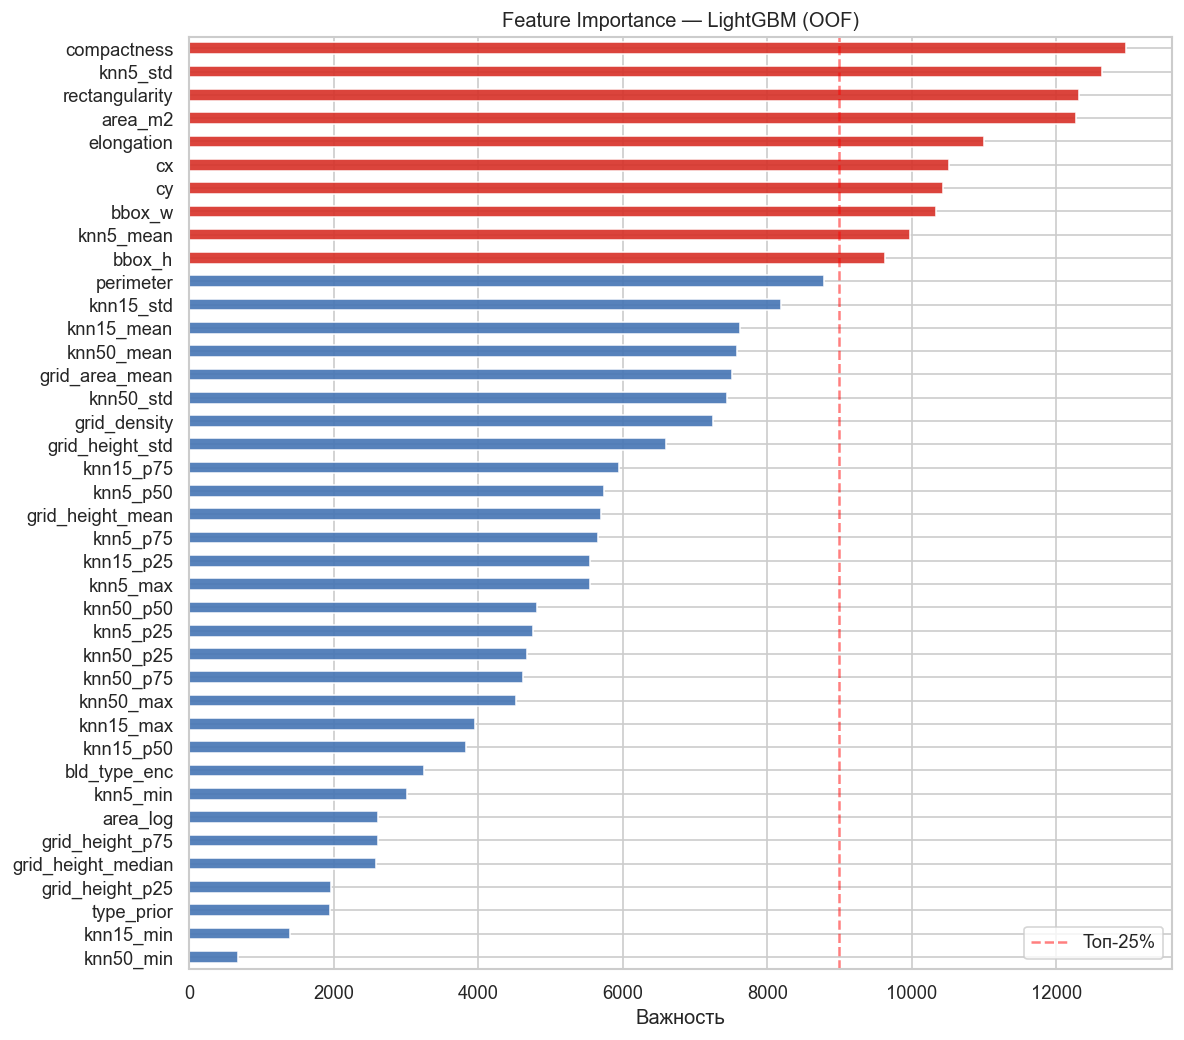


Топ-5 признаков:
  compactness                   : 12957.0000
  knn5_std                      : 12627.0000
  rectangularity                : 12308.0000
  area_m2                       : 12276.0000
  elongation                    : 11004.0000


In [43]:
if hasattr(final_model, 'feature_importances_'):
    fi = pd.Series(final_model.feature_importances_, index=FEAT_NAMES).sort_values()
    fig, ax = plt.subplots(figsize=(10, max(5, len(fi)*0.22)))
    clr = ['#d73027' if v > fi.quantile(0.75) else '#4575b4' for v in fi]
    fi.plot(kind='barh', ax=ax, color=clr, edgecolor='white', alpha=0.9)
    ax.axvline(fi.quantile(0.75), color='red', ls='--', alpha=0.5, label='Топ-25%')
    ax.set_xlabel('Важность')
    ax.set_title(f'Feature Importance — {best_name}')
    ax.legend()
    plt.tight_layout(); plt.savefig('feature_importance.png', bbox_inches='tight'); plt.show()

    top5 = fi.sort_values(ascending=False).head(5)
    print('\nТоп-5 признаков:')
    for name, val in top5.items():
        print(f'  {name:30s}: {val:.4f}')

## Шаг. Сохранение

In [45]:
train_eval_set['predicted_height'] = np.nan
train_eval_set['height_source']    = train_eval_set.get('height_source', pd.Series('known', index=train_eval_set.index))

gdf_out = gpd.GeoDataFrame(
    pd.concat([train_eval_set, predict_set], ignore_index=True),
    geometry='geometry', crs='EPSG:4326'
)

gdf_out['final_height'] = gdf_out['height'].combine_first(gdf_out.get('predicted_height'))

keep = ['building_id','final_height','height','predicted_height','height_source',
        'area_m2','centroid_lat','centroid_lon','bld_type','bld_type_median_h','geometry']
for c in ['stairs','name_street','number','district','gkh_address']:
    if c in gdf_out.columns: keep.append(c)
keep = [c for c in keep if c in gdf_out.columns]

gdf_out[keep].to_file('spb_buildings_final.gpkg', driver='GPKG')

print('Итог:')
print(f'  Зданий всего              : {len(gdf_out):,}')
print(f'  Высота известна (original): {gdf_out["height"].notna().sum():,}')
print(f'  Высота от ML              : {(gdf_out.get("height_source",pd.Series()) == "ml_predicted").sum():,}')
print(f'\n  OOF MAE                   : {best_row["MAE"]:.2f} м')
print(f'  OOF RMSE                  : {best_row["RMSE"]:.2f} м')
print(f'  OOF R²                    : {best_row["R2"]:.4f}')
print(f'  OOF MAPE                  : {best_row["MAPE%"]:.1f}%')
print(f'  OOF MedAE                 : {best_row["MedAE"]:.2f} м')
print(f'  OOF P90                   : {best_row["P90"]:.2f} м')

Итог:
  Зданий всего              : 225,656
  Высота известна (original): 150,681
  Высота от ML              : 74,975

  OOF MAE                   : 6.76 м
  OOF RMSE                  : 12.85 м
  OOF R²                    : 0.2913
  OOF MAPE                  : 57.9%
  OOF MedAE                 : 2.65 м
  OOF P90                   : 19.37 м


## Инсайты + Карта

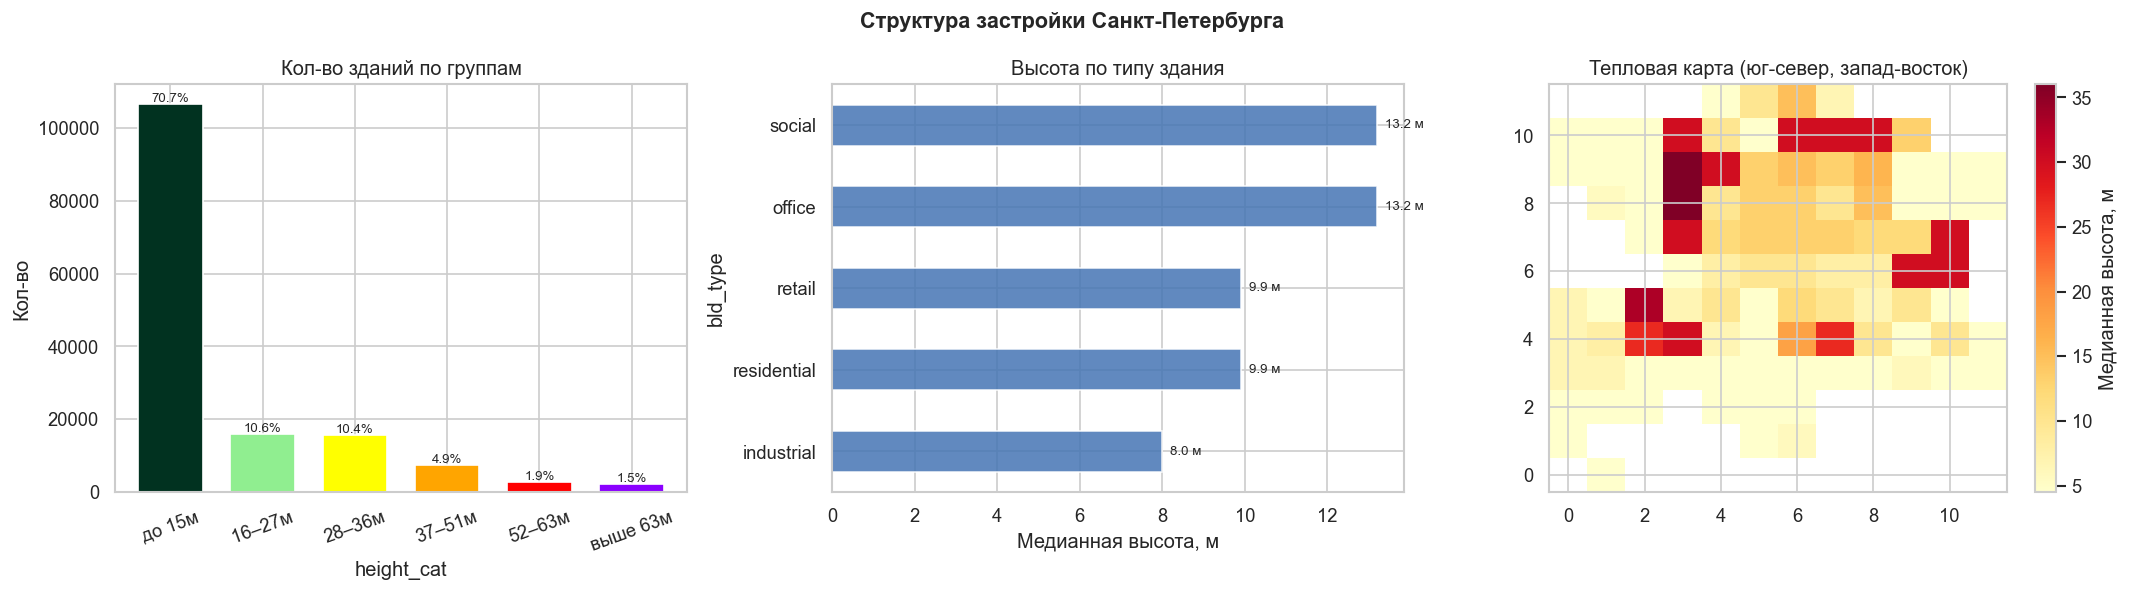

In [47]:
gdf_v = gdf_unified[gdf_unified['height'].notna() & (gdf_unified['height'] > 0)].copy()
if 'centroid_lat' not in gdf_v.columns:
    gdf_v['centroid_lat'] = gdf_v.geometry.centroid.y
    gdf_v['centroid_lon'] = gdf_v.geometry.centroid.x

gdf_v['height_cat'] = pd.cut(gdf_v['height'], bins=CARD_BINS, labels=CARD_LABELS)
cat_counts = gdf_v['height_cat'].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Структура застройки Санкт-Петербурга', fontsize=13, fontweight='bold')

ax = axes[0]
cat_counts.plot(kind='bar', ax=ax, color=CARD_COLORS[:len(cat_counts)], edgecolor='white', width=0.7)
ax.set_title('Кол-во зданий по группам'); ax.set_ylabel('Кол-во'); ax.tick_params(axis='x', rotation=20)
total = cat_counts.sum()
for i, (_, v) in enumerate(cat_counts.items()):
    ax.text(i, v + total*0.004, f'{v/total*100:.1f}%', ha='center', fontsize=8)

ax = axes[1]
if 'bld_type' in gdf_v.columns:
    ts = (gdf_v[gdf_v['bld_type']!='unknown'].groupby('bld_type')['height']
          .agg(['median','count']).query('count > 10').sort_values('median'))
    ts['median'].plot(kind='barh', ax=ax, color='#4575b4', edgecolor='white', alpha=0.85)
    ax.set_xlabel('Медианная высота, м'); ax.set_title('Высота по типу здания')
    for i, (_, r) in enumerate(ts.iterrows()):
        ax.text(r['median']+0.2, i, f"{r['median']:.1f} м", va='center', fontsize=8)

ax = axes[2]
gdf_v['lon_bin'] = pd.cut(gdf_v['centroid_lon'], bins=12, labels=False)
gdf_v['lat_bin'] = pd.cut(gdf_v['centroid_lat'], bins=12, labels=False)
heat = gdf_v.pivot_table(values='height', index='lat_bin', columns='lon_bin', aggfunc='median')
im = ax.imshow(heat, cmap='YlOrRd', aspect='auto', origin='lower')
plt.colorbar(im, ax=ax, label='Медианная высота, м')
ax.set_title('Тепловая карта (юг-север, запад-восток)')
plt.tight_layout(); plt.savefig('insights.png', bbox_inches='tight'); plt.show()

In [49]:
print('Карта высотности Санкт-Петербурга')
MAX_MAP = 220_000
gdf_map = gdf_out.sample(min(MAX_MAP, len(gdf_out)), random_state=42).copy()

gdf_map['map_height'] = gdf_map['final_height']

gdf_map['map_source'] = np.where(
    gdf_map['predicted_height'].notna(),
    'ML prediction',
    gdf_map['height_source'].fillna('unknown')
)

H_EDGES  = [0, 15, 27, 36, 51, 63, 9999]
H_LABELS = ['до 15 м', '16–27 м', '28–36 м', '37–51 м', '52–63 м', 'выше 63 м']
H_COLORS = ['#1a9850', '#66bd63', '#fdae61', '#f46d43', '#d73027', '#a50026']
GRAY     = '#CCCCCC'

h_arr     = gdf_map['map_height'].values.astype(float)
bin_idx   = np.clip(np.digitize(h_arr, H_EDGES[1:-1]), 0, len(H_COLORS)-1)
color_arr = np.where(np.isnan(h_arr) | (h_arr <= 0), GRAY, np.array(H_COLORS)[bin_idx])
gdf_map['_color'] = color_arr

m = folium.Map(location=[59.9311, 30.3609], zoom_start=12, tiles='CartoDB positron')

for color in [GRAY] + H_COLORS:
    subset = gdf_map[gdf_map['_color'] == color]
    if subset.empty:
        continue

    features = []
    for _, row in subset.iterrows():
        try:
            geom = row.geometry
            if geom is None or geom.is_empty:
                continue

            h = row.get('map_height', float('nan'))
            h_s = f'{h:.1f} м' if not np.isnan(h) else 'н/д'
            btype = row.get('bld_type', '?')
            src = row.get('map_source', '?')
            area = row.get('area_m2', 0) or 0

            features.append({
                'type': 'Feature',
                'geometry': geom.__geo_interface__,
                'properties': {
                    'popup': (
                        f'<b>Высота:</b> {h_s}<br>'
                        f'<b>Тип:</b> {btype}<br>'
                        f'<b>Источник высоты:</b> {src}<br>'
                        f'<b>Площадь:</b> {area:.0f} м²'
                    )
                }
            })
        except Exception:
            continue

    if not features:
        continue

    folium.GeoJson(
        {'type': 'FeatureCollection', 'features': features},
        style_function=lambda x, c=color: {
            'fillColor': c, 'color': c, 'weight': 0.3, 'fillOpacity': 0.78
        },
        popup=folium.GeoJsonPopup(fields=['popup'], labels=False)
    ).add_to(m)

# Легенда
rows = ''
for lbl, clr in zip(H_LABELS, H_COLORS):
    rows += (f'<div style="display:flex;align-items:center;margin:3px 0">'
             f'<span style="display:inline-block;width:14px;height:14px;background:{clr};border-radius:2px;margin-right:7px"></span>'
             f'{lbl}</div>')
rows += (f'<div style="display:flex;align-items:center;margin:3px 0">'
         f'<span style="display:inline-block;width:14px;height:14px;background:{GRAY};border-radius:2px;margin-right:7px"></span>'
         f'нет данных</div>')
m.get_root().html.add_child(folium.Element(
    f'<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;'
    f'padding:12px 16px;border-radius:8px;box-shadow:2px 2px 8px rgba(0,0,0,0.25);'
    f'font-family:Arial;font-size:12px"><b>Высота зданий</b><br>{rows}</div>'
))

m.save('spb_building_heights.html')
print('spb_building_heights.html')
from IPython.display import IFrame
IFrame('spb_building_heights.html', width='100%', height=560)

Карта высотности Санкт-Петербурга
spb_building_heights.html


In [51]:
if "predicted_height" not in train_eval_set.columns:
    train_eval_set["predicted_height"] = np.nan

if "predicted_height" not in predict_set.columns:
    predict_set["predicted_height"] = np.nan

if "height_source" not in train_eval_set.columns:
    train_eval_set["height_source"] = "source_known"

if "height_source" not in predict_set.columns:
    predict_set["height_source"] = "ml_predicted"

gdf_out = gpd.GeoDataFrame(
    pd.concat([train_eval_set, predict_set], ignore_index=True),
    geometry="geometry",
    crs="EPSG:4326"
)

gdf_out["final_height"] = gdf_out["height"].combine_first(gdf_out["predicted_height"])

gdf_csv = gdf_out.copy()
gdf_csv["geometry_wkt"] = gdf_csv.geometry.apply(lambda g: g.wkt if g is not None else None)

keep = [
    "building_id",
    "final_height",
    "height",
    "predicted_height",
    "height_source",
    "area_m2",
    "centroid_lat",
    "centroid_lon",
    "geometry_wkt"
]

for c in ["stairs", "bld_type", "bld_type_median_h", "name_street", "number", "district", "gkh_address"]:
    if c in gdf_csv.columns:
        keep.append(c)

keep = [c for c in keep if c in gdf_csv.columns]
gdf_csv[keep].to_csv("spb_buildings_unified.csv", index=False, encoding="utf-8-sig")

ml_count = gdf_csv["predicted_height"].notna().sum() if "predicted_height" in gdf_csv.columns else 0

print("Результаты:")
print(f'  Зданий всего         : {len(gdf_csv):,}')
print(f'  Высота из источников : {gdf_csv["height"].notna().sum():,}')
print(f'  Высота от ML         : {ml_count:,}')
print(f'  Итоговая высота      : {gdf_csv["final_height"].notna().sum():,}')
print(f'  OOF MAE              : {best_row["MAE"]:.2f} м')
print(f'  OOF R²               : {best_row["R2"]:.4f}')
print(f'  OOF MAPE             : {best_row["MAPE%"]:.1f}%')

Результаты:
  Зданий всего         : 225,656
  Высота из источников : 150,681
  Высота от ML         : 74,975
  Итоговая высота      : 225,656
  OOF MAE              : 6.76 м
  OOF R²               : 0.2913
  OOF MAPE             : 57.9%
